# Getting the data ready

In [1]:
import pandas as pd
import seaborn as sns


df = pd.read_csv('/content/dataset_2.csv')

In [2]:
df.columns

Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool', 'Price'],
      dtype='object')

## Data visualization

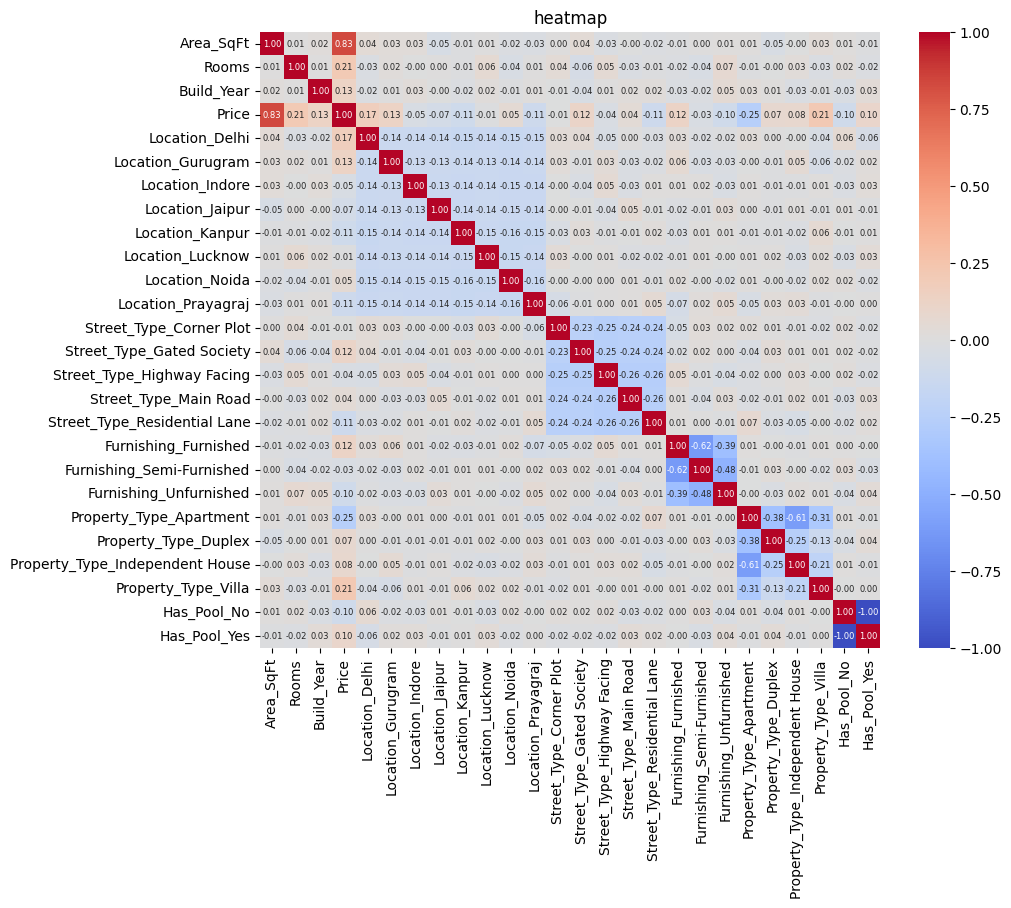

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot = True,
            cmap = 'coolwarm',
            fmt = '.2f',
            annot_kws={"size": 6})

plt.title('heatmap')
plt.show()

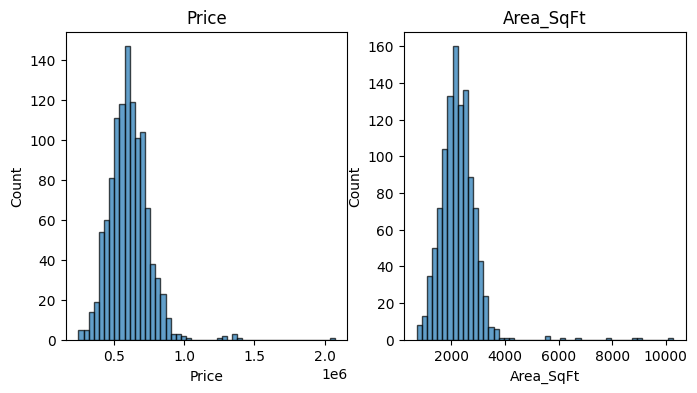

In [4]:
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
axes[0].hist(
		df["Price"],
		bins=50,
		edgecolor="black",
		alpha=0.7)
axes[0].set_title('Price')
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

axes[1].hist(
		df["Area_SqFt"],
		bins=50,
		edgecolor="black",
		alpha=0.7)
axes[1].set_title('Area_SqFt')

axes[1].set_xlabel("Area_SqFt")
axes[1].set_ylabel("Count")

plt.show()

In [5]:
import numpy as np

numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=['number']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Price'] = np.log1p(df['Price'])
df['Area_SqFt'] = np.log1p(df['Area_SqFt'])

df = pd.get_dummies(df)
df

,Area_SqFt,Rooms,Build_Year,Price,Location_Delhi,Location_Gurugram,Location_Indore,Location_Jaipur,Location_Kanpur,Location_Lucknow,...,Street_Type_Residential Lane,Furnishing_Furnished,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Property_Type_Apartment,Property_Type_Duplex,Property_Type_Independent House,Property_Type_Villa,Has_Pool_No,Has_Pool_Yes
0,7.813669,4.0,1992,13.250734,False,False,False,True,False,False,...,True,True,False,False,True,False,False,False,True,False
1,7.764072,4.0,2006,13.265970,False,False,True,False,False,False,...,False,False,False,True,True,False,False,False,False,True
2,7.702205,3.0,2012,13.273024,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
3,7.946223,6.0,1993,13.585613,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,True
4,7.534041,5.0,2012,13.108441,False,False,False,True,False,False,...,False,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119,7.808749,7.0,1988,13.458730,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False
1120,8.177284,7.0,1989,13.509434,False,False,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
1121,7.687484,4.0,2011,13.187212,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
1122,7.697369,6.0,2022,13.187096,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False


# Training the models

In [6]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [7]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


X = df.drop('Price', axis = 1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

gbr = GradientBoostingRegressor(n_estimators = 1000,
                                learning_rate = 0.01,
                                max_depth = 6,
                                random_state=42)
gbr.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators = 1000,
                   learning_rate = 0.01,
                   max_depth = 6,
                   n_jobs = -1,
                   random_state=42,
                   reg_lambda=1)

xgb.fit(X_train, y_train)

cbr = CatBoostRegressor(n_estimators = 1000,
                        learning_rate = 0.01,
                        max_depth = 6,
                        thread_count = -1,
                        random_state=42,
                        l2_leaf_reg=5,
                        verbose = False)
cbr.fit(X_train, y_train)

er = VotingRegressor([('gbr', gbr), ('xgb', xgb), ('cbr', cbr)])
er.fit(X_train, y_train)

VotingRegressor(estimators=[('gbr',
                             GradientBoostingRegressor(learning_rate=0.01,
                                                       max_depth=6,
                                                       n_estimators=1000,
                                                       random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_ty...
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=1000, n_jobs=-1,
                                          num_parallel_tree=None, ...)),
                            ('cbr',
                             CatBoostRegressor(l2_leaf_reg=5, learning_rate=0.01, loss_function='RMSE', max_depth=6, n_estimators=1000, random_state=42, verbose=False))])

# Evaluation

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

def evaluate(model, X_train, X_test, y_train, y_test):
    y_preds_real = np.expm1(model.predict(X_test))
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)

    overfitting = model.score(X_train, y_train)
    r2 = model.score(X_test, y_test)

    mae = mean_absolute_error(y_test_real, y_preds_real)
    mse = np.sqrt(mean_squared_error(y_test_real, y_preds_real))
    mape = (abs(y_test_real - y_preds_real) / y_test_real).mean() * 100
    cv = cross_val_score(er, X_train, y_train, cv = 5)

    return {
        'model': type(model).__name__,
        'overfitting (train R²)': round(overfitting, 4),
        'r2 (test)': round(r2, 4),
        'mae': round(mae, 2),
        'rmse': round(mse, 2),
        'mape': f'{round(mape, 2)}%',
        'cross_val': f'{cv.mean():.4f} ± {cv.std():.4f}'
    }

## VotingRegressor

In [9]:
evaluate(er, X_train, X_test, y_train, y_test)

{'model': 'VotingRegressor',
 'overfitting (train R²)': 0.9876,
 'r2 (test)': 0.9305,
 'mae': 25448.64,
 'rmse': np.float64(34289.59),
 'mape': '4.42%',
 'cross_val': '0.8934 ± 0.0139'}

## XGBoostRegressor

In [10]:
evaluate(xgb, X_train, X_test, y_train, y_test)

{'model': 'XGBRegressor',
 'overfitting (train R²)': 0.9929,
 'r2 (test)': 0.9144,
 'mae': 28397.07,
 'rmse': np.float64(39382.51),
 'mape': '4.89%',
 'cross_val': '0.8934 ± 0.0139'}

## CatBoostRegressor
(the best one)

In [11]:
evaluate(cbr, X_train, X_test, y_train, y_test)

{'model': 'CatBoostRegressor',
 'overfitting (train R²)': np.float64(0.9543),
 'r2 (test)': np.float64(0.9377),
 'mae': 23910.54,
 'rmse': np.float64(36288.89),
 'mape': '4.07%',
 'cross_val': '0.8934 ± 0.0139'}

## GradientBoostingRegressor

In [12]:
evaluate(gbr, X_train, X_test, y_train, y_test)

{'model': 'GradientBoostingRegressor',
 'overfitting (train R²)': 0.9967,
 'r2 (test)': 0.9143,
 'mae': 28053.72,
 'rmse': np.float64(37265.28),
 'mape': '4.91%',
 'cross_val': '0.8934 ± 0.0139'}

# Top 10 model features

In [13]:
def top_10_features(model, X):
  feature_dict = dict(zip(X.columns, model.feature_importances_))
  feature_X = pd.DataFrame(feature_dict, index = [0])
  feature_X.T.plot.bar(title = 'feature importance', legend = False)

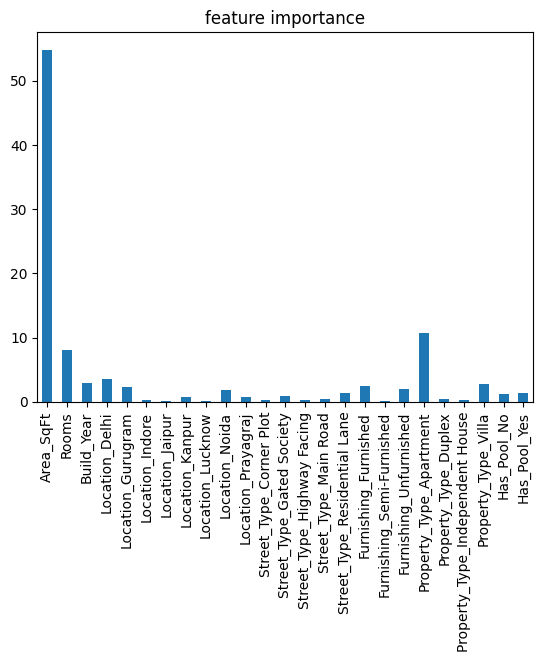

In [14]:
top_10_features(cbr, X)

# Save all models

In [17]:
import joblib

joblib.dump(er, 'VotingRegressor.pkl')
joblib.dump(cbr, 'CatBoostRegressor.pkl')
joblib.dump(xgb, 'XGBoostRegressor.pkl')
joblib.dump(gbr, 'GradientBoostingRegressor.pkl')

['GradientBoostingRegressor.pkl']